# **EMPLOYEE PROMOTION**

**Final project by Syntax Society**
- Bayu Maitra
- Dian Ulhaq
- Febiansyah Ahnaf
- Keisya Nisrina Aulia
- Maslahatul Husna

# **Import Tools & Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_project_kelompok_1/dataset/Rakamin Bootcamp - Dataset - Promotion Dataset.csv') # import dataset

df.sample(5)

,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible
714,EMP0715,42.0,10.0,2.0,91.0,45.0,14.0,73.0,Senior,0.0
642,EMP0643,37.0,2.0,5.0,38.0,170.0,14.0,52.0,Mid,0.0
739,EMP0740,46.0,10.0,5.0,6.0,105.0,5.0,59.0,Lead,0.0
286,EMP0287,22.0,6.0,NaN,21.0,52.0,15.0,NaN,Mid,0.0
454,EMP0455,41.0,16.0,4.0,12.0,NaN,11.0,27.0,Mid,0.0


In [ ]:
df.shape

(1000, 10)

In [ ]:
df_notes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_project_kelompok_1/dataset/Rakamin Bootcamp - Dataset - Promotion Dictionary.csv') # import keterangan dataset

df_notes

,Kolom,Deskripsi
0,Employee_ID,ID unik untuk tiap karyawan
1,Age,Usia karyawan (terdapat missing & anomali)
2,Years_at_Company,Lama bekerja di perusahaan (tahun)
3,Performance_Score,Skor performa tahunan (1–5)
4,Leadership_Score,Skor kepemimpinan (0–100)
5,Training_Hours,Jumlah jam pelatihan yang diikuti karyawan
6,Projects_Handled,Jumlah proyek yang pernah ditangani
7,Peer_Review_Score,Skor penilaian rekan kerja (0–100)
8,Current_Position_Level,"Level jabatan saat ini (Junior, Mid, Senior, L..."
9,Promotion_Eligible,"Label target: 1 = eligible dipromosikan, 0 = t..."


# **EDA**

In [ ]:
df.info() # cek kelengkapan dan tipe data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             1000 non-null   object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        951 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    float64
dtypes: float64(8), object(2)
memory usage: 78.3+ KB


In [ ]:
df.describe() # cek statistik deskriptif

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible
count,950.000000,951.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,40.940000,14.968454,2.969474,50.117895,109.286316,10.016842,51.227368,0.294737
std,12.863864,9.319084,1.417977,28.668058,184.616517,5.666507,29.141002,0.456165
min,-3.000000,-5.000000,1.000000,0.000000,-50.000000,0.000000,0.000000,0.000000
25%,31.000000,7.000000,2.000000,25.000000,51.250000,5.000000,25.000000,0.000000
50%,41.000000,15.000000,3.000000,51.000000,102.500000,10.000000,51.000000,0.000000
75%,50.000000,23.000000,4.000000,75.000000,150.750000,15.000000,78.000000,1.000000
max,200.000000,100.000000,5.000000,99.000000,5000.000000,19.000000,99.000000,1.000000


In [ ]:
df.isna().sum()

,0
Employee_ID,0
Age,50
Years_at_Company,49
Performance_Score,50
Leadership_Score,50
Training_Hours,50
Projects_Handled,50
Peer_Review_Score,50
Current_Position_Level,50
Promotion_Eligible,50


In [ ]:
df['Employee_ID'].duplicated().any()

np.False_

In [ ]:
df['Current_Position_Level'].value_counts()

,count
Current_Position_Level,
Mid,248
Lead,243
Junior,241
Senior,218


In [ ]:
df.columns

Index(['Employee_ID', 'Age', 'Years_at_Company', 'Performance_Score',
       'Leadership_Score', 'Training_Hours', 'Projects_Handled',
       'Peer_Review_Score', 'Current_Position_Level', 'Promotion_Eligible'],
      dtype='object')

In [ ]:
nums = ['Age', 'Years_at_Company', 'Performance_Score', 'Leadership_Score',
       'Training_Hours', 'Projects_Handled', 'Peer_Review_Score', 'Promotion_Eligible']
cats = ['Employee_ID', 'Current_Position_Level']



In [ ]:
df[nums].describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible
count,950.000000,951.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,40.940000,14.968454,2.969474,50.117895,109.286316,10.016842,51.227368,0.294737
std,12.863864,9.319084,1.417977,28.668058,184.616517,5.666507,29.141002,0.456165
min,-3.000000,-5.000000,1.000000,0.000000,-50.000000,0.000000,0.000000,0.000000
25%,31.000000,7.000000,2.000000,25.000000,51.250000,5.000000,25.000000,0.000000
50%,41.000000,15.000000,3.000000,51.000000,102.500000,10.000000,51.000000,0.000000
75%,50.000000,23.000000,4.000000,75.000000,150.750000,15.000000,78.000000,1.000000
max,200.000000,100.000000,5.000000,99.000000,5000.000000,19.000000,99.000000,1.000000


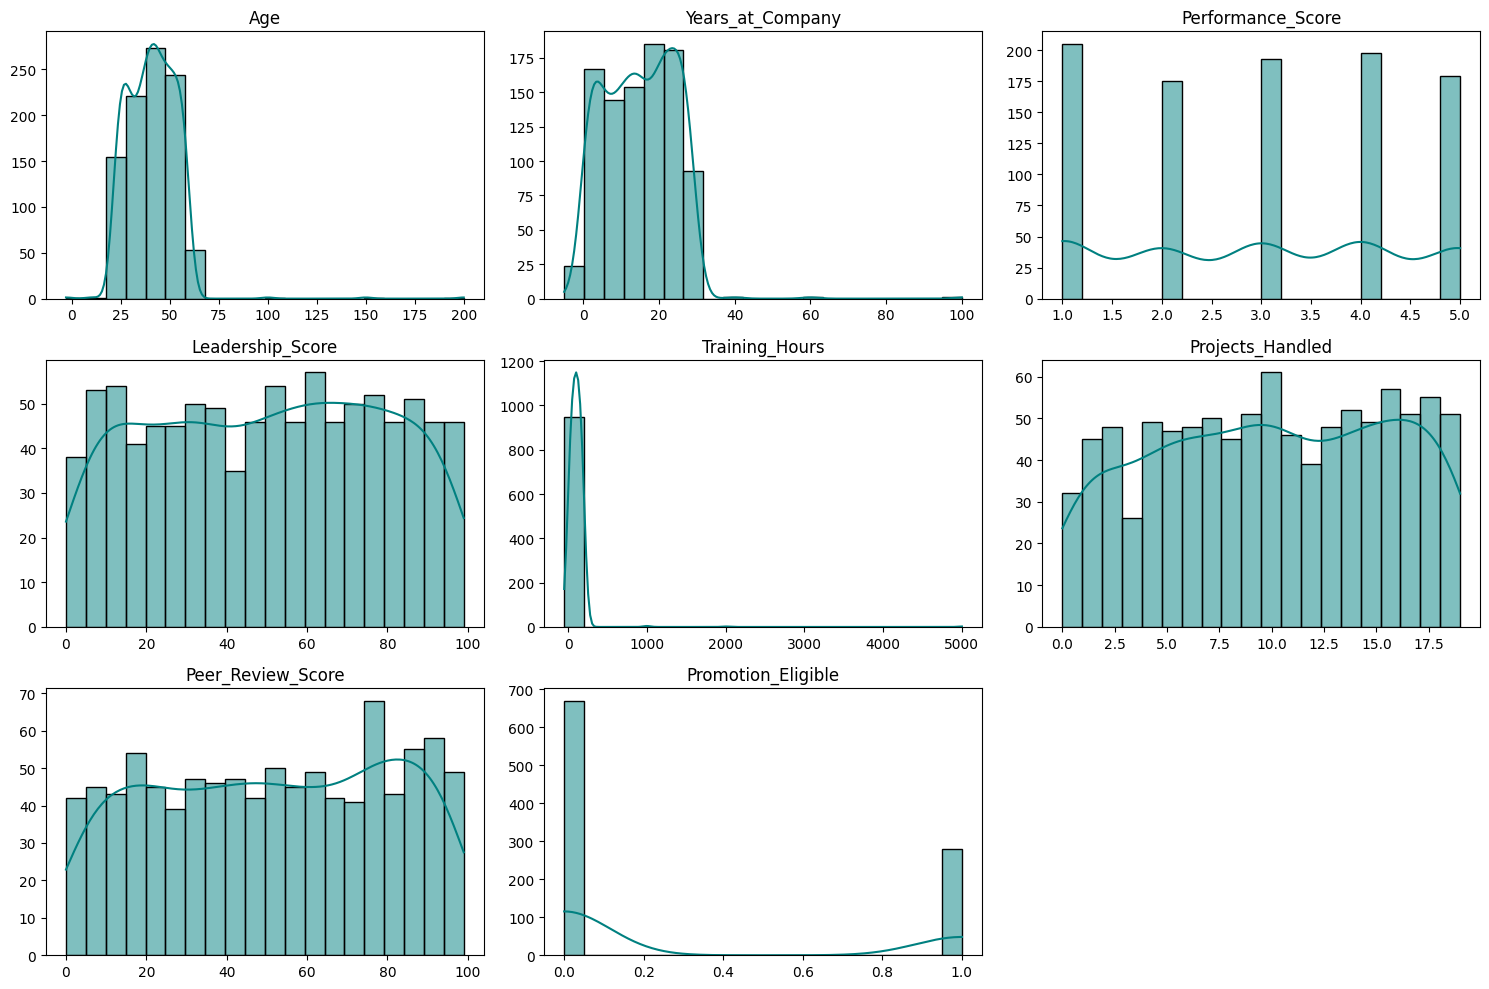

In [ ]:
# Asumsi: df = DataFrame utama, nums = list nama kolom numerik
n_cols = 3
n_rows = -(-len(nums) // n_cols)  # pembulatan ke atas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# Plot histogram untuk setiap kolom
for i, col in enumerate(nums):
    sns.histplot(df[col], ax=axes[i], kde=True, color='teal', bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Sembunyikan subplot kosong kalau kolom < jumlah grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

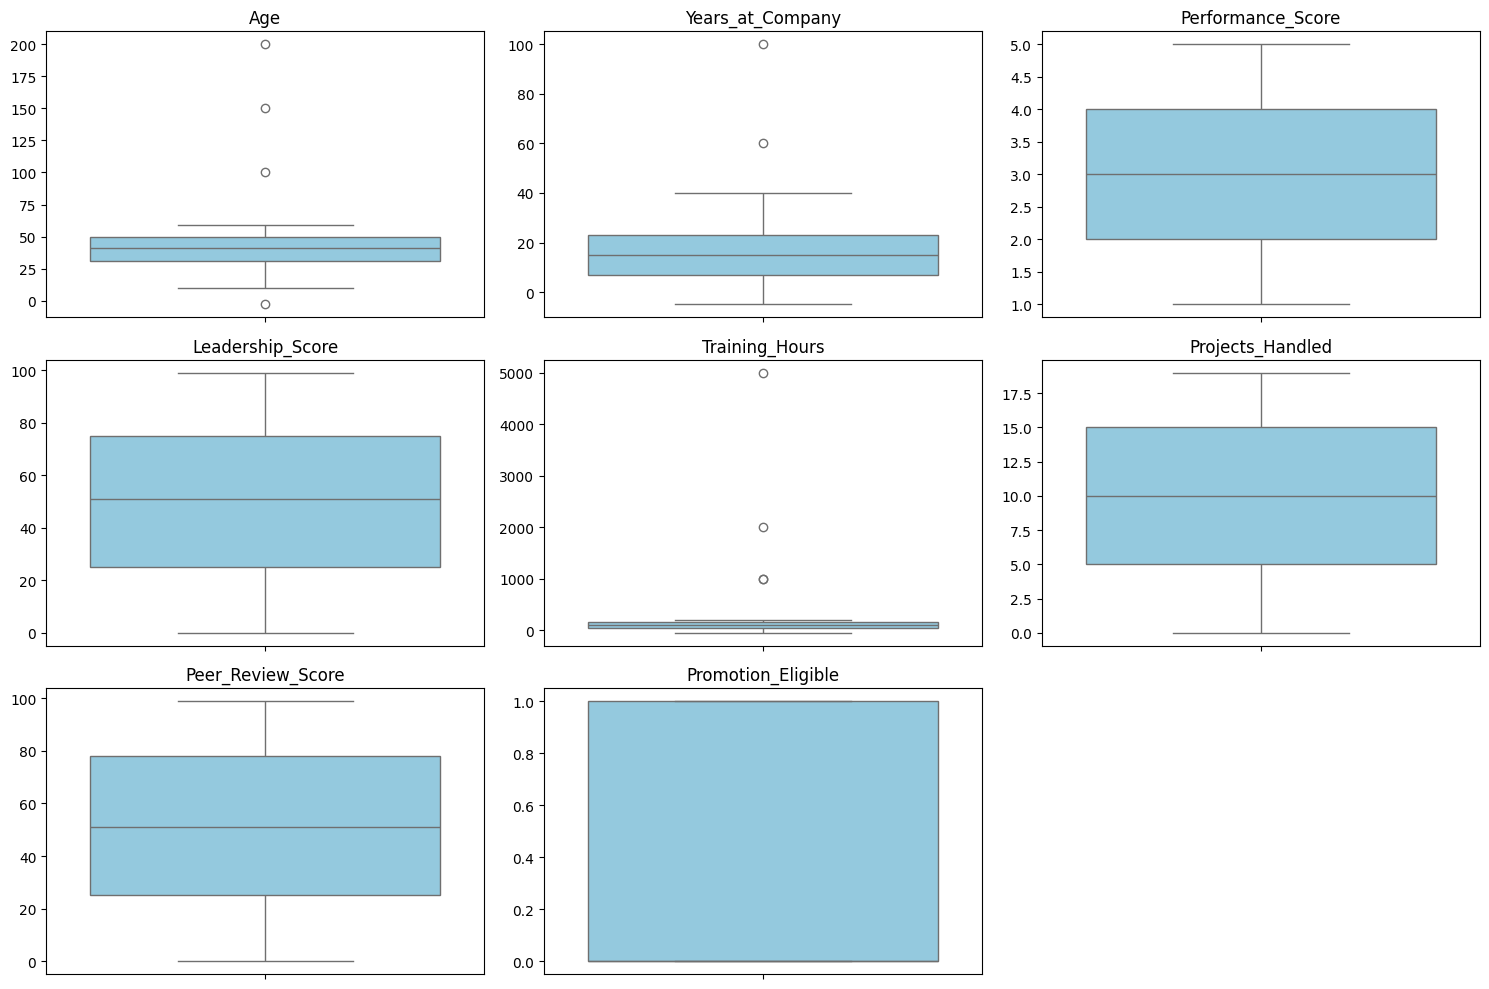

In [ ]:

# Grid 3x3 boxplot
n_cols = 3
n_rows = -(-len(nums) // n_cols)  # pembulatan ke atas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# Loop untuk membuat boxplot tiap kolom
for i, col in enumerate(nums):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Sembunyikan sumbu kosong (kalau kolom < jumlah grid)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

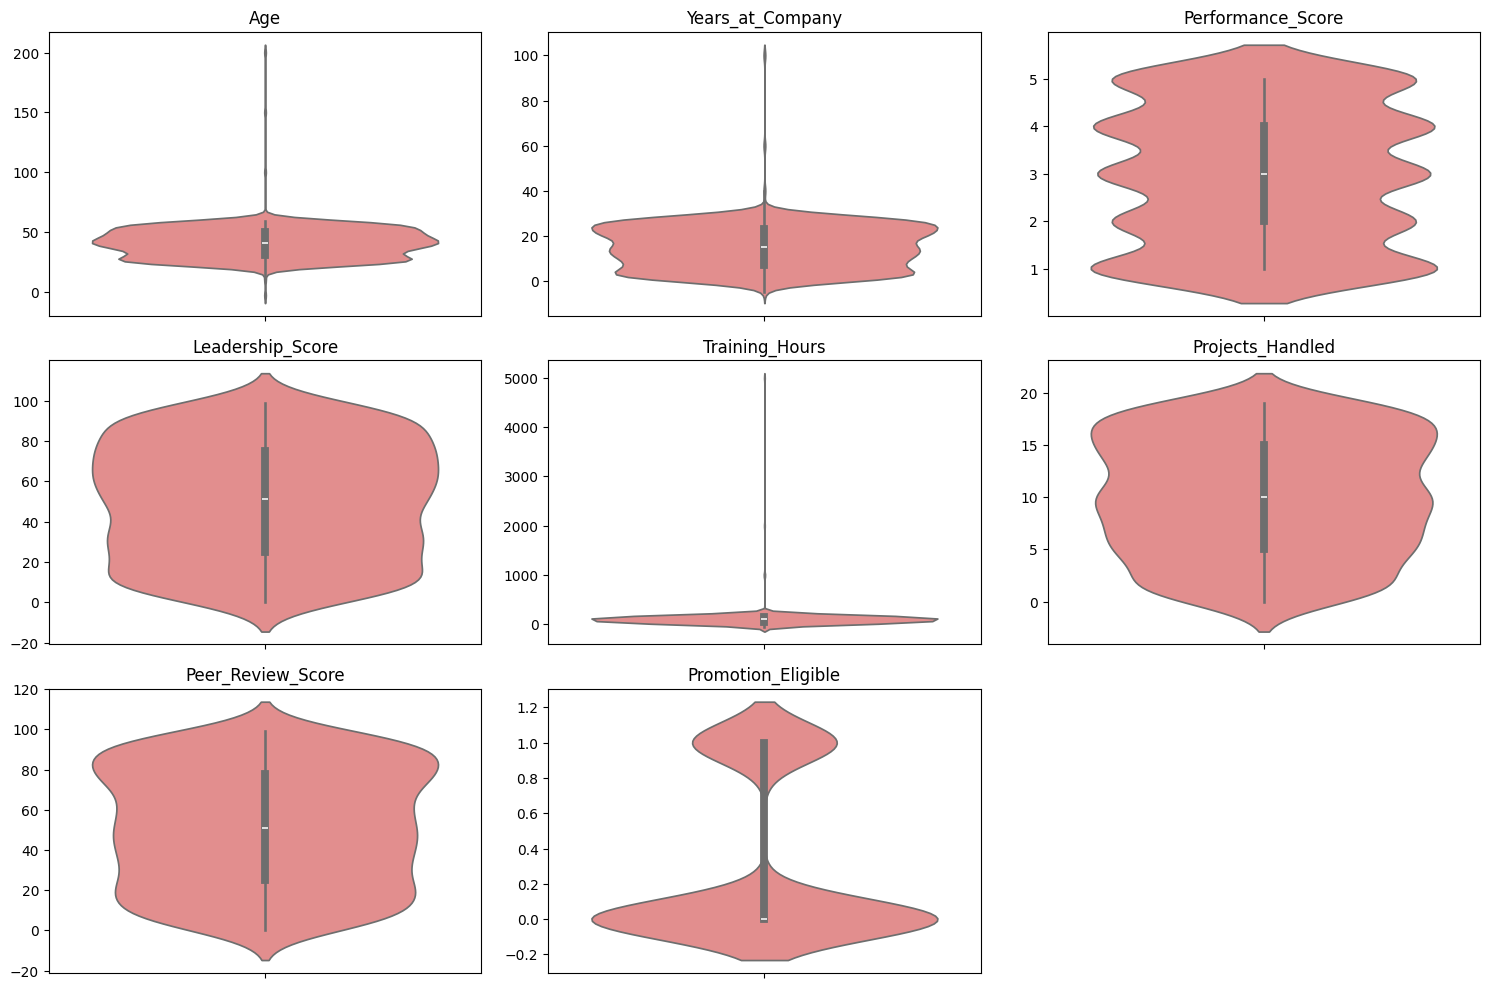

In [ ]:
# @title
# Asumsi df = DataFrame utama, nums = list nama kolom numerik
n_cols = 3
n_rows = -(-len(nums) // n_cols)  # pembulatan ke atas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# Plot violin untuk tiap kolom
for i, col in enumerate(nums):
    sns.violinplot(y=df[col], ax=axes[i], color='lightcoral', inner='box')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Sembunyikan subplot kosong (kalau kolom < jumlah grid)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
df[nums].corr()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible
Age,1.000000,-0.031913,0.024861,0.042142,-0.036789,-0.018498,-0.026909,-0.007665
Years_at_Company,-0.031913,1.000000,-0.016311,0.016476,-0.015400,0.020640,0.036773,-0.051958
Performance_Score,0.024861,-0.016311,1.000000,-0.041303,-0.008569,0.000592,0.011103,-0.020456
Leadership_Score,0.042142,0.016476,-0.041303,1.000000,0.032143,-0.065101,-0.015485,-0.036065
Training_Hours,-0.036789,-0.015400,-0.008569,0.032143,1.000000,0.004077,0.040814,-0.016548
Projects_Handled,-0.018498,0.020640,0.000592,-0.065101,0.004077,1.000000,-0.034854,0.054244
Peer_Review_Score,-0.026909,0.036773,0.011103,-0.015485,0.040814,-0.034854,1.000000,0.019121
Promotion_Eligible,-0.007665,-0.051958,-0.020456,-0.036065,-0.016548,0.054244,0.019121,1.000000


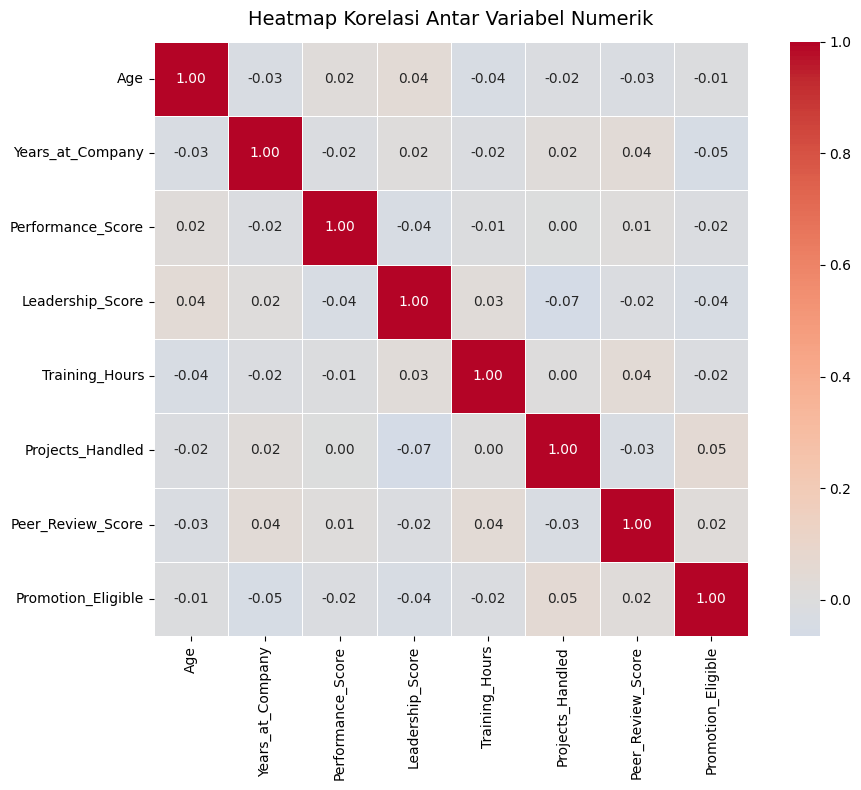

In [ ]:
# Hitung korelasi antar kolom numerikal
corr = df[nums].corr()

# Atur ukuran figure
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,        # tampilkan nilai korelasi di dalam sel
    cmap='coolwarm',   # palet warna biru–merah
    center=0,          # tengah peta warna di 0
    fmt=".2f",         # dua angka di belakang koma
    linewidths=0.5,    # garis pemisah antar sel
    square=True        # agar kotaknya proporsional
)

plt.title("Heatmap Korelasi Antar Variabel Numerik", fontsize=14, pad=12)
plt.tight_layout()
plt.show()